<a href="https://colab.research.google.com/github/Santiago-1505/Laboratorio-3-Imagenes/blob/main/lab3_imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA 3 — Clasificación de Residuos con CoAtNet
## Dataset: Garbage Classification v2 (Kaggle — sumn2u)

---

## Estructura del notebook

| Sección | Descripción | Puntaje |
|---------|-------------|---------|
| **Punto 1** | Explicación detallada de cada capa de CoAtNet | 40% |
| **Punto 2** | Implementación completa con resultados y presentación | 60% |

---

**Red seleccionada:** CoAtNet (Convolution + Attention Network)  
**Dataset:** Garbage Classification v2 — 10 clases, ~13.348 imágenes  
**Framework:** PyTorch + timm  
**Entorno:** Google Colab (GPU T4)

---
# PUNTO 1 (40%) — Explicación de cada capa de CoAtNet

## ¿Qué es CoAtNet?

**CoAtNet** (*Convolution and Attention Network*) es una arquitectura híbrida propuesta por Google Brain en 2021 (Dai et al., *CoAtNet: Marrying Convolution and Attention for All Data Sizes*). Su idea central es combinar la **inductive bias** de las convoluciones (localidad espacial, invarianza a traslaciones) con la **capacidad de modelar dependencias globales** de los Transformers, logrando lo mejor de ambos mundos.

---

## Arquitectura General

CoAtNet se organiza en **5 etapas (S0 a S4)**, donde las primeras etapas usan convoluciones (capas MBConv) y las últimas usan atención (capas Transformer relativa). La variante `coatnet_0` tiene la siguiente estructura:

```
Entrada (224×224×3)
    │
    ▼
[S0] Stem — Conv 3×3, stride 2  →  112×112×64
    │
    ▼
[S1] MBConv × 2 (depthwise sep. conv) — stride 2  →  56×56×96
    │
    ▼
[S2] MBConv × 6 (depthwise sep. conv) — stride 2  →  28×28×192
    │
    ▼
[S3] Transformer (Self-Attention relativa) × 14 — stride 2  →  14×14×384
    │
    ▼
[S4] Transformer (Self-Attention relativa) × 2 — stride 2  →  7×7×768
    │
    ▼
Global Average Pooling → 768
    │
    ▼
Clasificador (Linear) → NUM_CLASSES
```

---

## Descripción de cada capa

### 🔹 Capa 1 — Stem (S0): Extracción de características de bajo nivel

**Tipo:** Convolución estándar 3×3, stride=2, seguida de BatchNorm y activación GELU.

**¿Qué hace?**  
Es la primera capa que recibe la imagen cruda (224×224×3). Aplica un banco de filtros convolucionales que detectan **bordes, texturas y gradientes básicos** — las primitivas visuales más elementales. El stride=2 reduce la resolución espacial a la mitad (112×112) para hacer el cómputo eficiente desde el inicio.

**¿Por qué convolución aquí?**  
Los Transformers tienen dificultad aprendiendo desde imágenes crudas sin suficiente datos. La convolución actúa como un *encoder* inicial que produce representaciones locales estables antes de aplicar atención global.

**Parámetros clave:**  
- Entrada: 224×224×3  
- Salida: 112×112×64  
- Operación: `Conv2d(3, 64, kernel=3, stride=2, padding=1)` → `BatchNorm` → `GELU`

---

### 🔹 Capa 2 — S1: Bloque MBConv (Mobile Inverted Bottleneck Convolution)

**Tipo:** Bloque residual MBConv con convolución depthwise separable + Squeeze-and-Excitation (SE).

**¿Qué hace?**  
Los bloques MBConv vienen de **MobileNetV2/EfficientNet** y son altamente eficientes. Cada bloque:
1. **Expansión (pointwise 1×1):** Expande los canales por un factor (ej. ×4).
2. **Convolución Depthwise 3×3:** Filtra espacialmente *cada canal por separado* — muy eficiente en parámetros.
3. **Módulo SE (Squeeze-and-Excitation):** Recalibra la importancia de cada canal mediante un mecanismo de atención de canal global (`GlobalAvgPool → FC → ReLU → FC → Sigmoid`).
4. **Proyección (pointwise 1×1):** Reduce los canales de vuelta al tamaño original.
5. **Conexión residual:** Suma la entrada con la salida (skip connection).

**¿Por qué aquí?**  
A resoluciones altas (56×56), la atención global sería computacionalmente prohibitiva (coste O(n²)). Las convoluciones capturan patrones locales de forma eficiente.

**Parámetros clave:**  
- Entrada: 112×112×64  
- Salida: 56×56×96  
- Bloques: 2 repeticiones

---

### 🔹 Capa 3 — S2: Bloques MBConv más profundos

**Tipo:** Igual que S1 pero con más bloques (×6) y mayor número de canales.

**¿Qué hace?**  
Continúa extrayendo características locales pero de **nivel semántico intermedio**: texturas complejas, formas parciales, patrones repetitivos. La mayor profundidad (6 bloques) permite aprender representaciones más abstractas sin dejar la localidad espacial.

**Diferencia con S1:**  
- Más canales (192 vs 96): mayor capacidad de representación.
- Más bloques (6 vs 2): extracción más profunda.
- La resolución baja a 28×28, haciendo que la atención global empiece a ser viable en la siguiente etapa.

**Parámetros clave:**  
- Entrada: 56×56×96  
- Salida: 28×28×192  
- Bloques: 6 repeticiones

---

### 🔹 Capa 4 — S3: Bloques Transformer con Atención Relativa de Posición

**Tipo:** Transformer con **Multi-Head Self-Attention (MHSA) y codificación relativa de posición**, seguido de una red feedforward (MLP).

**¿Qué hace?**  
Esta es la primera etapa de atención. Cada bloque contiene:
1. **LayerNorm:** Normalización de la secuencia de tokens (cada parche 14×14 es un token).
2. **Multi-Head Self-Attention con bias relativo:** Cada token atiende a *todos los demás tokens* de la imagen. El **bias relativo de posición** codifica la distancia relativa entre parches, permitiendo al modelo entender la estructura espacial sin necesitar posiciones absolutas.
3. **Conexión residual:** Suma de la entrada.
4. **LayerNorm + MLP (2 capas FC con GELU):** Transforma cada token de forma independiente.
5. **Segunda conexión residual.**

**¿Por qué se introduce la atención aquí?**  
A resolución 14×14, la secuencia tiene solo 196 tokens → el coste O(196²) es perfectamente manejable. Aquí el modelo empieza a capturar **relaciones globales**: por ejemplo, relacionar la textura del plástico con su forma general.

**Innovación clave — bias relativo vs posición absoluta:**  
A diferencia del ViT original que usa posiciones absolutas, CoAtNet usa *bias* de posición relativa entre pares de tokens, lo que le da mejor generalización a diferentes tamaños de imagen.

**Parámetros clave:**  
- Entrada: 28×28×192  
- Salida: 14×14×384  
- Bloques: 14 repeticiones

---

### 🔹 Capa 5 — S4: Bloques Transformer finales (alta abstracción)

**Tipo:** Igual que S3 pero con mayor dimensionalidad y menor resolución espacial.

**¿Qué hace?**  
Con solo 7×7=49 tokens y 768 canales, estos bloques aprenden representaciones de **muy alto nivel semántico**: la identidad de objetos completos. A esta etapa, el modelo integra toda la información global de la imagen para generar una representación compacta y discriminativa de cada clase (ej: distinguir entre *plástico* vs *vidrio*).

**Parámetros clave:**  
- Entrada: 14×14×384  
- Salida: 7×7×768  
- Bloques: 2 repeticiones

---

### 🔹 Capa 6 — Cabeza de Clasificación

**Tipo:** Global Average Pooling (GAP) + capa Linear (Fully Connected).

**¿Qué hace?**
1. **Global Average Pooling:** Promedia los 7×7 tokens de cada canal → vector de 768 dimensiones. Reduce todos los mapas espaciales a un único vector de características por imagen.
2. **Dropout (opcional):** Regularización para evitar sobreajuste.
3. **Linear (768 → NUM_CLASSES):** Proyección final al espacio de clases. Cada neurona de salida corresponde a una clase de residuo.

**Salida:** Logits sin activación (se usa `CrossEntropyLoss` que incluye Softmax internamente).

---

## Resumen visual de la arquitectura CoAtNet-0

| Etapa | Tipo | Resolución Salida | Canales | Bloques | Operación Principal |
|-------|------|:-----------------:|:-------:|:-------:|---------------------|
| S0 — Stem | Conv estándar | 112×112 | 64 | 1 | Conv 3×3 stride=2 + BN + GELU |
| S1 | MBConv | 56×56 | 96 | 2 | DepthwiseConv + SE + Skip conn. |
| S2 | MBConv | 28×28 | 192 | 6 | DepthwiseConv + SE + Skip conn. |
| S3 | Transformer | 14×14 | 384 | 14 | MHSA (pos. relativa) + MLP |
| S4 | Transformer | 7×7 | 768 | 2 | MHSA (pos. relativa) + MLP |
| Head | GAP + Linear | — | NUM_CLASSES | 1 | GlobalAvgPool + FC |

## ¿Por qué CoAtNet para clasificación de residuos?

- **Imágenes heterogéneas:** Las basuras tienen texturas locales (plástico brillante, cartón rugoso) *y* formas globales (zapatos, baterías). CoAtNet captura ambas.
- **Transfer Learning efectivo:** Los pesos preentrenados en ImageNet-21k ya codifican millones de conceptos visuales reutilizables.
- **Eficiencia:** `coatnet_0` tiene ~25M parámetros, manejable en una GPU T4.

---
# PUNTO 2 (60%) — Implementación Completa con CoAtNet

## Pipeline:
1. Importación del dataset desde Kaggle
2. Exploración y análisis exploratorio (EDA)
3. Preprocesamiento y Data Augmentation
4. Carga del modelo CoAtNet preentrenado
5. Entrenamiento con scheduler y early stopping
6. Evaluación: accuracy, loss, matriz de confusión, reporte de clasificación
7. Visualización de predicciones
8. Conclusiones

---
## Paso 1 — Importación del Dataset desde Kaggle

Usamos `kagglehub` para descargar el dataset directamente en Colab. La versión `standardized_256` contiene imágenes ya redimensionadas a 256×256 píxeles, lo que acelera el preprocesamiento.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 1: Descarga del dataset desde Kaggle usando kagglehub
# kagglehub gestiona la autenticación y el caché automáticamente en Colab.
# Si ya fue descargado antes, usa la versión en caché (más rápido).
# ─────────────────────────────────────────────────────────────────────────────
import kagglehub

# Descargar la última versión del dataset
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

print("✅ Dataset descargado correctamente")
print("📁 Ruta del dataset:", path)

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
✅ Dataset descargado correctamente
📁 Ruta del dataset: /kaggle/input/garbage-classification-v2


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 1b: Verificar la estructura de carpetas del dataset
# El dataset tiene 3 versiones de imágenes:
#   - original: tamaños variables
#   - standardized_256: imágenes 256×256 (usaremos esta)
#   - standardized_384: imágenes 384×384
# Usamos standardized_256 porque CoAtNet espera 224×224 y es más rápido de cargar.
# ─────────────────────────────────────────────────────────────────────────────
import os

# Listar carpetas disponibles en el dataset
print("📂 Contenido del dataset:")
!ls {path}

print("\n📂 Clases en standardized_256:")
!ls {path+"/standardized_256"}

📂 Contenido del dataset:
original  standardized_256  standardized_384

📂 Clases en standardized_256:
battery     cardboard  glass  paper    shoes
biological  clothes    metal  plastic  trash


---
## Paso 2 — Análisis Exploratorio de Datos (EDA)

Antes de entrenar, es fundamental entender la distribución del dataset:
- ¿Cuántas imágenes hay por clase?
- ¿Hay desbalance de clases?
- ¿Cómo lucen las imágenes de cada categoría?


📊 Distribución del dataset:
   Total de clases : 10
   Total de imágenes: 12259
   Clase más grande: clothes (1892 imgs)
   Clase más pequeña: trash (453 imgs)
   Ratio desbalance: 4.2x



,Clase,Cantidad
0,clothes,1892
1,glass,1736
2,plastic,1597
3,shoes,1449
4,cardboard,1411
5,paper,1336
6,metal,930
7,battery,756
8,biological,699
9,trash,453


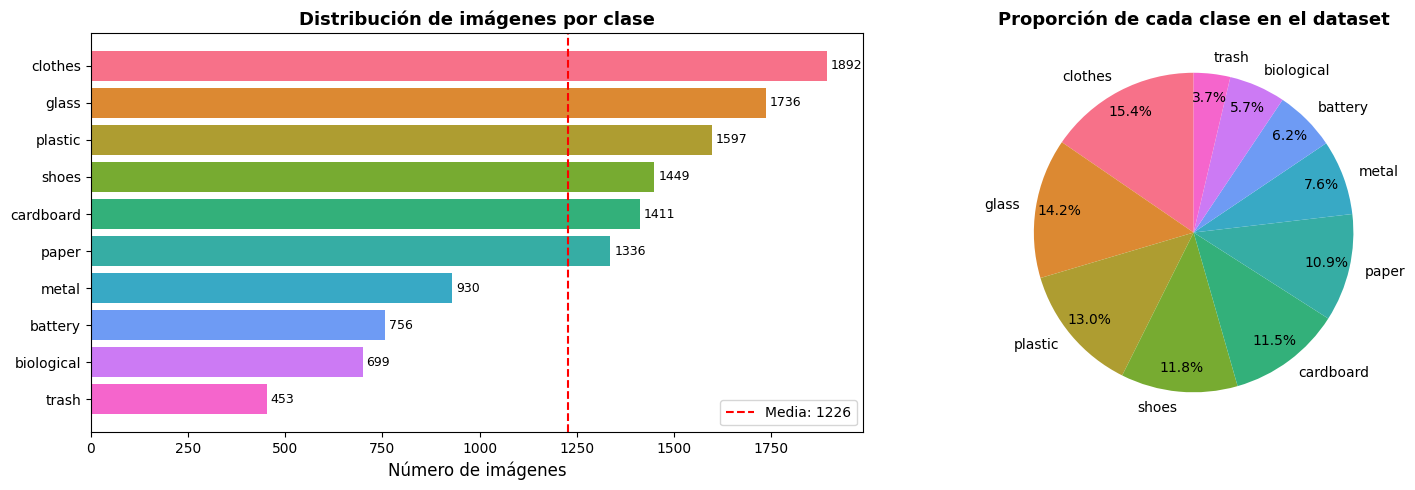

💡 Nota: Existe cierto desbalance (ratio ~4.2x entre 'clothes' y 'trash').
   Se considerará esto al evaluar métricas por clase.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 2a: Contar imágenes por clase y visualizar la distribución
# Esto nos ayuda a detectar desbalance de clases, lo que podría afectar
# el entrenamiento y requerir técnicas como class weighting o oversampling.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Ruta a las imágenes estandarizadas de 256×256
data_dir = os.path.join(path, 'standardized_256')

# Obtener la lista de clases (subcarpetas) y contar imágenes en cada una
classes_raw = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

stats = []
for cls in classes_raw:
    count = len([f for f in os.listdir(os.path.join(data_dir, cls))
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
    stats.append({'Clase': cls, 'Cantidad': count})

# Crear DataFrame ordenado de mayor a menor cantidad
df_stats = pd.DataFrame(stats).sort_values(by='Cantidad', ascending=False).reset_index(drop=True)

print(f"\n📊 Distribución del dataset:")
print(f"   Total de clases : {len(classes_raw)}")
print(f"   Total de imágenes: {df_stats['Cantidad'].sum()}")
print(f"   Clase más grande: {df_stats.iloc[0]['Clase']} ({df_stats.iloc[0]['Cantidad']} imgs)")
print(f"   Clase más pequeña: {df_stats.iloc[-1]['Clase']} ({df_stats.iloc[-1]['Cantidad']} imgs)")
print(f"   Ratio desbalance: {df_stats.iloc[0]['Cantidad'] / df_stats.iloc[-1]['Cantidad']:.1f}x")
print()
display(df_stats)

# ── Visualización: Gráfico de barras con conteo por clase ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Paleta de colores diferenciada por clase
colors = sns.color_palette("husl", len(df_stats))

# Gráfico de barras horizontal
bars = axes[0].barh(df_stats['Clase'], df_stats['Cantidad'], color=colors)
axes[0].set_xlabel('Número de imágenes', fontsize=12)
axes[0].set_title('Distribución de imágenes por clase', fontsize=13, fontweight='bold')
axes[0].axvline(df_stats['Cantidad'].mean(), color='red', linestyle='--', label=f'Media: {df_stats["Cantidad"].mean():.0f}')
# Añadir etiquetas con el número exacto en cada barra
for bar, val in zip(bars, df_stats['Cantidad']):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[0].legend(fontsize=10)
axes[0].invert_yaxis()  # La clase más grande arriba

# Gráfico de torta con proporciones
axes[1].pie(df_stats['Cantidad'], labels=df_stats['Clase'], autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.85)
axes[1].set_title('Proporción de cada clase en el dataset', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Nota: Existe cierto desbalance (ratio ~4.2x entre 'clothes' y 'trash').")
print("   Se considerará esto al evaluar métricas por clase.")

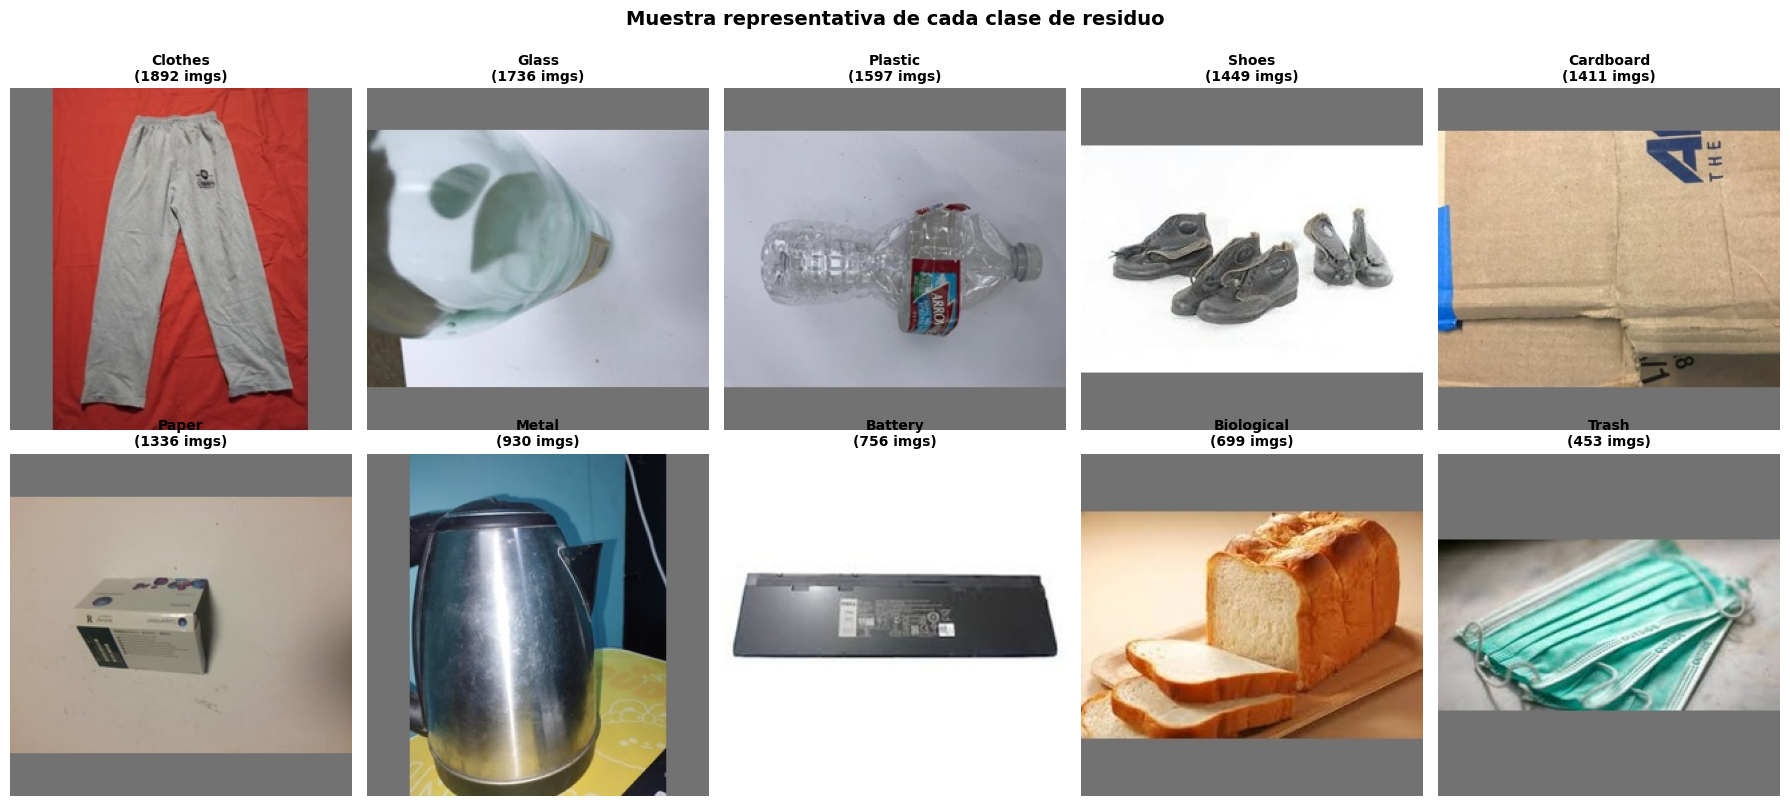

✅ Muestras visualizadas. Las imágenes tienen buena calidad y variedad dentro de cada clase.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 2b: Visualizar imágenes de muestra de cada clase
# Es fundamental ver cómo lucen las imágenes para entender el problema:
# - Variabilidad dentro de cada clase
# - Similitudes entre clases (posibles fuentes de confusión)
# - Calidad general de las imágenes
# ─────────────────────────────────────────────────────────────────────────────
from PIL import Image
import random

# Fijar semilla para reproducibilidad de las muestras mostradas
random.seed(42)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(df_stats['Clase']):
    cls_path = os.path.join(data_dir, cls)
    # Obtener lista de archivos de imagen válidos
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    # Seleccionar una imagen aleatoria de la clase
    sample_img = random.choice(imgs)
    img = Image.open(os.path.join(cls_path, sample_img)).convert('RGB')

    axes[i].imshow(img)
    axes[i].set_title(f'{cls.capitalize()}\n({df_stats[df_stats["Clase"]==cls]["Cantidad"].values[0]} imgs)',
                      fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Muestra representativa de cada clase de residuo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('muestras_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Muestras visualizadas. Las imágenes tienen buena calidad y variedad dentro de cada clase.")

---
## Paso 3 — Preprocesamiento y Data Augmentation

El preprocesamiento adapta las imágenes al formato esperado por CoAtNet:
- **Resize a 224×224:** Tamaño estándar del modelo preentrenado.
- **Data Augmentation (solo en train):** Aumenta artificialmente la diversidad del dataset para mejorar la generalización y reducir el sobreajuste.
- **Normalización ImageNet:** Los pesos preentrenados fueron entrenados con imágenes normalizadas con media=[0.485, 0.456, 0.406] y std=[0.229, 0.224, 0.225].

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 3: Definir transformaciones con Data Augmentation
#
# Para ENTRENAMIENTO aplicamos augmentation (perturbaciones aleatorias):
#   - RandomHorizontalFlip: La basura puede aparecer de cualquier orientación.
#   - RandomRotation(15°): Pequeñas rotaciones simulan diferentes ángulos de cámara.
#   - ColorJitter: Variaciones de brillo/contraste simulan diferentes condiciones de luz.
#   - RandomResizedCrop: Recortes aleatorios simulan diferentes distancias al objeto.
#
# Para VALIDACIÓN solo resize + center crop + normalización (sin augmentation):
#   - Evaluar en datos consistentes permite comparar épocas correctamente.
# ─────────────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

# Hiperparámetros globales
IMG_SIZE    = 224          # Tamaño de entrada estándar para CoAtNet
BATCH_SIZE  = 32           # Número de imágenes por batch (ajustar según memoria GPU)
NUM_WORKERS = 2            # Hilos paralelos para cargar datos
EPOCHS      = 10           # Número de épocas de entrenamiento completo
LR          = 1e-4         # Tasa de aprendizaje inicial (AdamW)
WEIGHT_DECAY = 1e-2        # Regularización L2 del optimizador
SEED        = 42           # Semilla para reproducibilidad

# Fijar semilla global para reproducibilidad en PyTorch y NumPy
torch.manual_seed(SEED)
np.random.seed(SEED)

# Detectar dispositivo disponible (GPU si está disponible, sino CPU)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Dispositivo de cómputo: {DEVICE}")
if DEVICE == 'cuda':
    print(f"   GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Transformaciones para el conjunto de ENTRENAMIENTO ─────────────────────
train_transforms = transforms.Compose([
    # 1. Redimensionar y recortar aleatoriamente para simular diferentes distancias
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    # 2. Voltear horizontalmente con probabilidad 50% (la basura no tiene orientación fija)
    transforms.RandomHorizontalFlip(p=0.5),
    # 3. Rotación aleatoria ±15° (diferentes ángulos de captura)
    transforms.RandomRotation(degrees=15),
    # 4. Ajustes de color para simular diferentes condiciones de iluminación
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    # 5. Convertir imagen PIL a tensor PyTorch (valores de 0.0 a 1.0)
    transforms.ToTensor(),
    # 6. Normalizar con estadísticas de ImageNet (requerido para pesos preentrenados)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ── Transformaciones para VALIDACIÓN (sin augmentation) ────────────────────
val_transforms = transforms.Compose([
    # 1. Redimensionar para que el lado menor sea IMG_SIZE+32 (para el crop central)
    transforms.Resize(IMG_SIZE + 32),
    # 2. Recorte central estándar al tamaño esperado por el modelo
    transforms.CenterCrop(IMG_SIZE),
    # 3. Convertir a tensor
    transforms.ToTensor(),
    # 4. Normalizar igual que entrenamiento
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Transformaciones definidas:")
print("   Train: RandomResizedCrop + HFlip + Rotation + ColorJitter + Normalize")
print("   Val:   Resize + CenterCrop + Normalize")

🖥️  Dispositivo de cómputo: cuda
   GPU detectada: Tesla T4
   Memoria GPU disponible: 15.6 GB
✅ Transformaciones definidas:
   Train: RandomResizedCrop + HFlip + Rotation + ColorJitter + Normalize
   Val:   Resize + CenterCrop + Normalize


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 3b: Cargar el dataset y dividir en train/validación
#
# ImageFolder espera la estructura: data_dir/clase/imagen.jpg
# Que es exactamente como está organizado nuestro dataset.
#
# División: 80% entrenamiento / 20% validación (split aleatorio estratificado)
# Nota: Aplicamos transforms diferentes a cada split usando Subset + overriding.
# ─────────────────────────────────────────────────────────────────────────────
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

# Cargar dataset completo con transforms de validación primero (para obtener índices)
full_dataset = datasets.ImageFolder(root=data_dir, transform=val_transforms)
NUM_CLASSES = len(full_dataset.classes)
class_names = full_dataset.classes  # Lista de nombres de clases

# Obtener todas las etiquetas para hacer split estratificado
all_labels = [label for _, label in full_dataset.samples]

# Split estratificado: mantiene la misma proporción de clases en train y val
train_indices, val_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels  # Garantiza representación proporcional de todas las clases
)

# Crear subsets: train con augmentation, val sin augmentation
# Creamos datasets separados con sus respectivas transforms
train_dataset_full = datasets.ImageFolder(root=data_dir, transform=train_transforms)
val_dataset_full   = datasets.ImageFolder(root=data_dir, transform=val_transforms)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset   = Subset(val_dataset_full,   val_indices)

# Crear DataLoaders (iteradores que sirven batches al modelo)
# pin_memory=True: precargar datos en memoria GPU para mayor velocidad
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,              # Mezclar orden en cada época (evita patrones de orden)
    num_workers=NUM_WORKERS,   # Carga paralela de datos
    pin_memory=True            # Acelera transferencia CPU→GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,             # No mezclar en validación (consistencia)
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Dataset cargado y dividido correctamente:")
print(f"   Total de imágenes  : {len(full_dataset)}")
print(f"   Train              : {len(train_dataset)} ({len(train_dataset)/len(full_dataset)*100:.0f}%)")
print(f"   Validación         : {len(val_dataset)} ({len(val_dataset)/len(full_dataset)*100:.0f}%)")
print(f"   Clases             : {class_names}")
print(f"   Número de clases   : {NUM_CLASSES}")
print(f"   Batches por época  : {len(train_loader)} (train) / {len(val_loader)} (val)")

✅ Dataset cargado y dividido correctamente:
   Total de imágenes  : 12259
   Train              : 9807 (80%)
   Validación         : 2452 (20%)
   Clases             : ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
   Número de clases   : 10
   Batches por época  : 307 (train) / 77 (val)


---
## Paso 4 — Carga del Modelo CoAtNet Preentrenado

Usamos **Transfer Learning**: cargamos pesos preentrenados en ImageNet-1k y reemplazamos la cabeza de clasificación para adaptarla a nuestras 10 clases de residuos. Esto aprovecha el conocimiento visual ya aprendido (bordes, texturas, formas) y requiere muchos menos datos y tiempo de entrenamiento.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 4a: Instalar timm si no está disponible
# timm (PyTorch Image Models) es la librería de referencia para modelos de visión.
# Contiene más de 700 arquitecturas preentrenadas incluyendo CoAtNet.
# ─────────────────────────────────────────────────────────────────────────────
!pip install timm -q
print("✅ timm instalado/verificado")

✅ timm instalado/verificado


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 4b: Inicializar CoAtNet-0 con pesos preentrenados
#
# timm.create_model() hace 3 cosas automáticamente:
#   1. Construye la arquitectura CoAtNet-0
#   2. Descarga y carga pesos preentrenados en ImageNet
#   3. Reemplaza la capa de clasificación final por una nueva Linear(768, NUM_CLASSES)
#      (La nueva cabeza se inicializa aleatoriamente y se entrena desde cero)
#
# ¿Por qué coatnet_0_rw_224?
#   - coatnet_0: la variante más pequeña (~25M parámetros) — buena para T4
#   - rw: 'Ross Wightman' variant — implementación optimizada en timm
#   - 224: tamaño de entrada en el que fue preentrenado
# ─────────────────────────────────────────────────────────────────────────────
model = timm.create_model(
    'coatnet_0_rw_224',   # Nombre del modelo en el registro de timm
    pretrained=True,       # Cargar pesos preentrenados en ImageNet
    num_classes=NUM_CLASSES  # Adaptar la cabeza final a nuestras 10 clases
)

# Mover el modelo a GPU (si está disponible) para entrenamiento acelerado
model = model.to(DEVICE)

# ── Estadísticas del modelo ──────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Modelo CoAtNet-0 cargado exitosamente")
print(f"   Arquitectura    : {model.default_cfg['architecture']}")
print(f"   Dispositivo     : {DEVICE}")
print(f"   Total parámetros: {total_params:,}")
print(f"   Paráms entrenables: {trainable_params:,}")
print(f"   Clases de salida : {NUM_CLASSES}")

✅ Modelo CoAtNet-0 cargado exitosamente
   Arquitectura    : coatnet_0_rw_224
   Dispositivo     : cuda
   Total parámetros: 26,674,252
   Paráms entrenables: 26,674,252
   Clases de salida : 10


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 4c: Configurar función de pérdida, optimizador y scheduler
#
# FUNCIÓN DE PÉRDIDA:
#   CrossEntropyLoss: estándar para clasificación multiclase.
#   label_smoothing=0.1: en lugar de targets 0/1 duros, usa 0.05/0.95.
#   Esto reduce el sobreajuste al evitar que el modelo sea demasiado 'confiado'.
#
# OPTIMIZADOR:
#   AdamW: variante de Adam con weight decay desacoplado.
#   - Adam adapta la tasa de aprendizaje por parámetro.
#   - weight_decay=1e-2 aplica regularización L2 real (sin afectar momentums).
#   Es el optimizador estándar para Transformers y modelos híbridos.
#
# SCHEDULER (ajuste de LR durante entrenamiento):
#   CosineAnnealingLR: reduce LR siguiendo una curva cosenoidal.
#   - Empieza en LR máximo, baja suavemente hasta LR mínimo.
#   - Permite 'calentar' primero (alta LR explora) y luego 'enfriar' (baja LR converge).
#   - T_max=EPOCHS: un ciclo completo a lo largo de todos los epochs.
# ─────────────────────────────────────────────────────────────────────────────

# Función de pérdida con suavizado de etiquetas
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizador AdamW
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Scheduler de tasa de aprendizaje cosenoidal
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,   # Número de iteraciones para completar un ciclo
    eta_min=1e-6    # LR mínimo al final del ciclo
)

print("✅ Configuración de entrenamiento:")
print(f"   Pérdida    : CrossEntropyLoss (label_smoothing=0.1)")
print(f"   Optimizador: AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"   Scheduler  : CosineAnnealingLR (T_max={EPOCHS}, eta_min=1e-6)")
print(f"   Épocas     : {EPOCHS}")

✅ Configuración de entrenamiento:
   Pérdida    : CrossEntropyLoss (label_smoothing=0.1)
   Optimizador: AdamW (lr=0.0001, weight_decay=0.01)
   Scheduler  : CosineAnnealingLR (T_max=10, eta_min=1e-6)
   Épocas     : 10


---
## Paso 5 — Entrenamiento del Modelo

Entrenamos el modelo durante múltiples épocas, guardando el mejor modelo (según validación) para evitar sobreajuste. En cada época:
1. **Fase de entrenamiento:** El modelo actualiza sus pesos con backpropagation.
2. **Fase de validación:** Evaluamos sin actualizar pesos para medir generalización.
3. **Checkpoint:** Guardamos el modelo si mejora la accuracy de validación.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 5a: Definir funciones de entrenamiento y validación por época
# ─────────────────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Entrena el modelo durante una época completa.

    Proceso por cada batch:
    1. Mover imágenes y etiquetas a GPU.
    2. Limpiar gradientes del batch anterior (zero_grad).
    3. Forward pass: el modelo genera predicciones (logits).
    4. Calcular la pérdida entre predicciones y etiquetas reales.
    5. Backward pass: calcular gradientes de la pérdida respecto a los pesos.
    6. Actualizar pesos del modelo según los gradientes (optimizer.step).
    7. Acumular métricas de pérdida y aciertos.

    Retorna: pérdida promedio y accuracy (%) de la época.
    """
    model.train()  # Activa capas de entrenamiento: Dropout, BatchNorm en modo train
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        # 1. Mover datos al dispositivo (GPU/CPU)
        images, labels = images.to(device), labels.to(device)

        # 2. Limpiar gradientes acumulados del batch anterior
        optimizer.zero_grad()

        # 3. Forward pass: calcular logits (salida sin softmax)
        outputs = model(images)      # Shape: (batch_size, NUM_CLASSES)

        # 4. Calcular la pérdida CrossEntropy
        loss = criterion(outputs, labels)

        # 5. Backward pass: calcular gradientes ∂Loss/∂W
        loss.backward()

        # 6. Actualizar pesos: W = W - lr * gradientes
        optimizer.step()

        # 7. Acumular métricas
        running_loss += loss.item() * images.size(0)  # Pérdida total del batch
        _, predicted = outputs.max(1)                 # Clase con mayor logit
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()  # Contar aciertos

    # Promediar pérdida y calcular accuracy de la época
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """
    Evalúa el modelo en el conjunto de validación (sin actualizar pesos).

    Proceso:
    - torch.no_grad(): deshabilita el cálculo de gradientes para ahorrar
      memoria y acelerar la evaluación (no necesitamos backpropagation).
    - El modelo usa BatchNorm/Dropout en modo eval (diferente a train).

    Retorna: pérdida promedio y accuracy (%) de validación.
    """
    model.eval()   # Activa modo evaluación: Dropout desactivado, BatchNorm usa stats globales
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():   # No calcular gradientes (más eficiente en memoria)
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc


print("✅ Funciones de entrenamiento y validación definidas")

✅ Funciones de entrenamiento y validación definidas


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 5b: Loop de entrenamiento principal con guardado del mejor modelo
#
# Estrategia 'Best Model Checkpoint':
#   - Evaluamos en validación después de cada época.
#   - Si la val_acc mejora, guardamos el modelo como 'mejor modelo'.
#   - Al final, cargamos el mejor modelo (no el del último epoch).
#   Esto protege contra el sobreajuste al final del entrenamiento.
# ─────────────────────────────────────────────────────────────────────────────
import time

# Listas para registrar el historial de entrenamiento (para gráficas posteriores)
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'lr':         []
}

best_val_acc = 0.0      # Mejor accuracy de validación vista hasta ahora
best_epoch   = 0        # Época en que se logró el mejor accuracy

print("=" * 70)
print(f"  🚀 INICIANDO ENTRENAMIENTO — CoAtNet-0 | {EPOCHS} épocas | GPU: {DEVICE}")
print("=" * 70)
print(f"{'Época':>5} | {'LR':>8} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8} | {'Tiempo':>7}")
print("-" * 70)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Fase 1: Entrenamiento ─────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # ── Fase 2: Validación ────────────────────────────────────────────────
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)

    # ── Fase 3: Actualizar scheduler (ajustar LR para la siguiente época) ─
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    # ── Registrar historial ───────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # ── Guardar mejor modelo ──────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        # Guardar estado completo del modelo (pesos + arquitectura)
        torch.save(model.state_dict(), 'best_coatnet_model.pth')
        checkpoint_marker = " ✅ MEJOR"  # Indicador visual en el log
    else:
        checkpoint_marker = ""

    epoch_time = time.time() - epoch_start
    print(f"{epoch:>5} | {current_lr:.2e} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>8.4f} | {val_acc:>7.2f}%{checkpoint_marker} | {epoch_time:>5.1f}s")

total_time = time.time() - total_start
print("-" * 70)
print(f"\n✅ Entrenamiento completado en {total_time/60:.1f} minutos")
print(f"🏆 Mejor modelo: Época {best_epoch} con Val Acc = {best_val_acc:.2f}%")
print(f"   Modelo guardado en: best_coatnet_model.pth")

  🚀 INICIANDO ENTRENAMIENTO — CoAtNet-0 | 10 épocas | GPU: cuda
Época |       LR | Train Loss | Train Acc | Val Loss |  Val Acc |  Tiempo
----------------------------------------------------------------------
    1 | 1.00e-04 |     0.8465 |    86.01% |   0.7153 |   91.60% ✅ MEJOR | 188.9s
    2 | 9.76e-05 |     0.6521 |    93.94% |   0.6375 |   94.25% ✅ MEJOR | 185.4s
    3 | 9.05e-05 |     0.5953 |    96.27% |   0.6376 |   94.45% ✅ MEJOR | 184.7s
    4 | 7.96e-05 |     0.5596 |    97.84% |   0.6331 |   94.78% ✅ MEJOR | 185.1s
    5 | 6.58e-05 |     0.5429 |    98.40% |   0.6222 |   94.86% ✅ MEJOR | 184.9s
    6 | 5.05e-05 |     0.5213 |    99.34% |   0.6132 |   95.51% ✅ MEJOR | 184.2s
    7 | 3.52e-05 |     0.5132 |    99.61% |   0.5994 |   95.96% ✅ MEJOR | 184.4s
    8 | 2.14e-05 |     0.5091 |    99.81% |   0.6022 |   95.84% | 184.1s
    9 | 1.05e-05 |     0.5079 |    99.85% |   0.5939 |   96.21% ✅ MEJOR | 185.0s
   10 | 3.42e-06 |     0.5058 |    99.91% |   0.5922 |   96.29% ✅ MEJO

---
## Paso 6 — Curvas de Entrenamiento

Visualizamos cómo evolucionaron la pérdida y el accuracy a lo largo de las épocas. Esto nos permite detectar:
- **Sobreajuste (overfitting):** Train acc sube pero val acc se estanca o baja.
- **Subajuste (underfitting):** Ambas métricas son bajas.
- **Convergencia saludable:** Train y val acc suben juntas y se estabilizan.

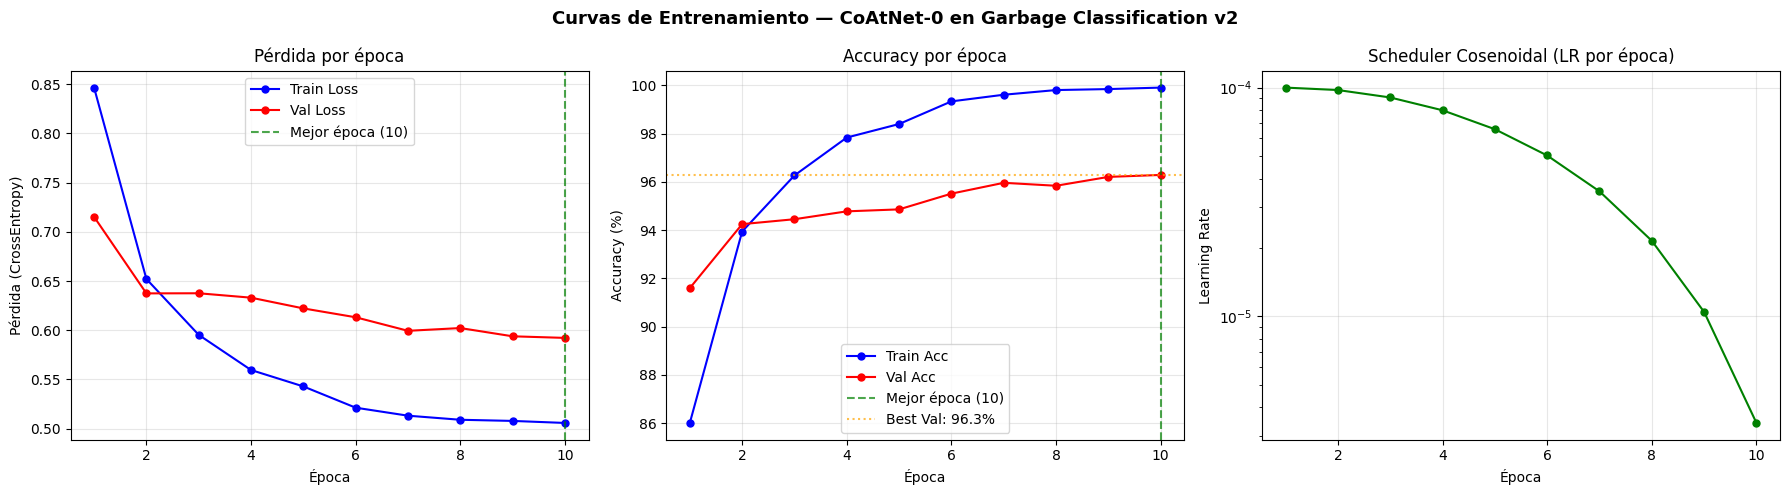


📊 Resumen del entrenamiento:
   Mejor Val Accuracy : 96.29% (Época 10)
   Train Acc final    : 99.91%
   Val Acc final      : 96.29%
   Brecha train-val   : 3.62% (generalización saludable)


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 6: Graficar curvas de entrenamiento
# ─────────────────────────────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas de Entrenamiento — CoAtNet-0 en Garbage Classification v2',
             fontsize=13, fontweight='bold')

# ── Gráfica 1: Curvas de pérdida ──────────────────────────────────────────
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=5)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=5)
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor época ({best_epoch})')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (CrossEntropy)')
axes[0].set_title('Pérdida por época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Gráfica 2: Curvas de accuracy ─────────────────────────────────────────
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=5)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc',   markersize=5)
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor época ({best_epoch})')
axes[1].axhline(best_val_acc, color='orange', linestyle=':', alpha=0.7, label=f'Best Val: {best_val_acc:.1f}%')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy por época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Gráfica 3: Evolución de la tasa de aprendizaje ────────────────────────
axes[2].plot(epochs_range, history['lr'], 'g-o', markersize=5)
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Scheduler Cosenoidal (LR por época)')
axes[2].set_yscale('log')  # Escala logarítmica para mejor visualización
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen numérico del entrenamiento
print(f"\n📊 Resumen del entrenamiento:")
print(f"   Mejor Val Accuracy : {best_val_acc:.2f}% (Época {best_epoch})")
print(f"   Train Acc final    : {history['train_acc'][-1]:.2f}%")
print(f"   Val Acc final      : {history['val_acc'][-1]:.2f}%")
gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f"   Brecha train-val   : {gap:.2f}% ({'sobreajuste leve' if gap > 5 else 'generalización saludable'})")

---
## Paso 7 — Evaluación Detallada del Mejor Modelo

Cargamos el mejor modelo guardado y realizamos una evaluación exhaustiva:
- **Matriz de confusión:** Muestra qué clases se confunden entre sí.
- **Reporte de clasificación:** Precision, Recall y F1-score por clase.
- **Accuracy global** en el conjunto de validación.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 7a: Cargar el mejor modelo guardado durante el entrenamiento
# ─────────────────────────────────────────────────────────────────────────────
# Cargar los pesos del mejor checkpoint
model.load_state_dict(torch.load('best_coatnet_model.pth', map_location=DEVICE))
model.eval()  # Poner en modo evaluación

print(f"✅ Mejor modelo cargado (Época {best_epoch}, Val Acc = {best_val_acc:.2f}%)")

✅ Mejor modelo cargado (Época 10, Val Acc = 96.29%)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 7b: Obtener todas las predicciones sobre el conjunto de validación
#
# Para métricas más ricas (precision, recall, F1, matriz de confusión) necesitamos
# las predicciones y etiquetas reales de TODOS los ejemplos de validación.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

all_preds  = []   # Lista para acumular predicciones
all_labels = []   # Lista para acumular etiquetas reales
all_probs  = []   # Lista para acumular probabilidades (para análisis adicional)

print("🔄 Generando predicciones sobre el conjunto de validación...")

model.eval()
with torch.no_grad():   # Sin gradientes para mayor eficiencia
    for images, labels in val_loader:
        images = images.to(DEVICE)

        # Forward pass: obtener logits
        outputs = model(images)                           # (batch, 10)

        # Convertir logits a probabilidades con softmax
        probs = torch.softmax(outputs, dim=1)             # (batch, 10)

        # Obtener clase predicha (argmax de probabilidades)
        _, predicted = outputs.max(1)                     # (batch,)

        # Acumular en listas CPU (numpy)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

# Convertir a arrays numpy para usar con sklearn
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Calcular accuracy global
final_acc = accuracy_score(all_labels, all_preds) * 100

print(f"\n✅ Evaluación completada sobre {len(all_labels)} imágenes de validación")
print(f"🎯 Accuracy global: {final_acc:.2f}%")

print("\n" + "=" * 65)
print("📋 REPORTE DE CLASIFICACIÓN POR CLASE:")
print("=" * 65)
print(classification_report(
    all_labels, all_preds,
    target_names=[c.capitalize() for c in class_names],
    digits=3   # 3 decimales para mayor precisión
))

🔄 Generando predicciones sobre el conjunto de validación...

✅ Evaluación completada sobre 2452 imágenes de validación
🎯 Accuracy global: 96.29%

📋 REPORTE DE CLASIFICACIÓN POR CLASE:
              precision    recall  f1-score   support

     Battery      1.000     0.967     0.983       151
  Biological      0.993     0.964     0.978       140
   Cardboard      0.945     0.968     0.956       282
     Clothes      0.992     0.995     0.993       379
       Glass      0.966     0.974     0.970       347
       Metal      0.928     0.973     0.950       186
       Paper      0.912     0.933     0.922       267
     Plastic      0.964     0.934     0.949       319
       Shoes      0.986     0.997     0.991       290
       Trash      0.926     0.824     0.872        91

    accuracy                          0.963      2452
   macro avg      0.961     0.953     0.957      2452
weighted avg      0.963     0.963     0.963      2452



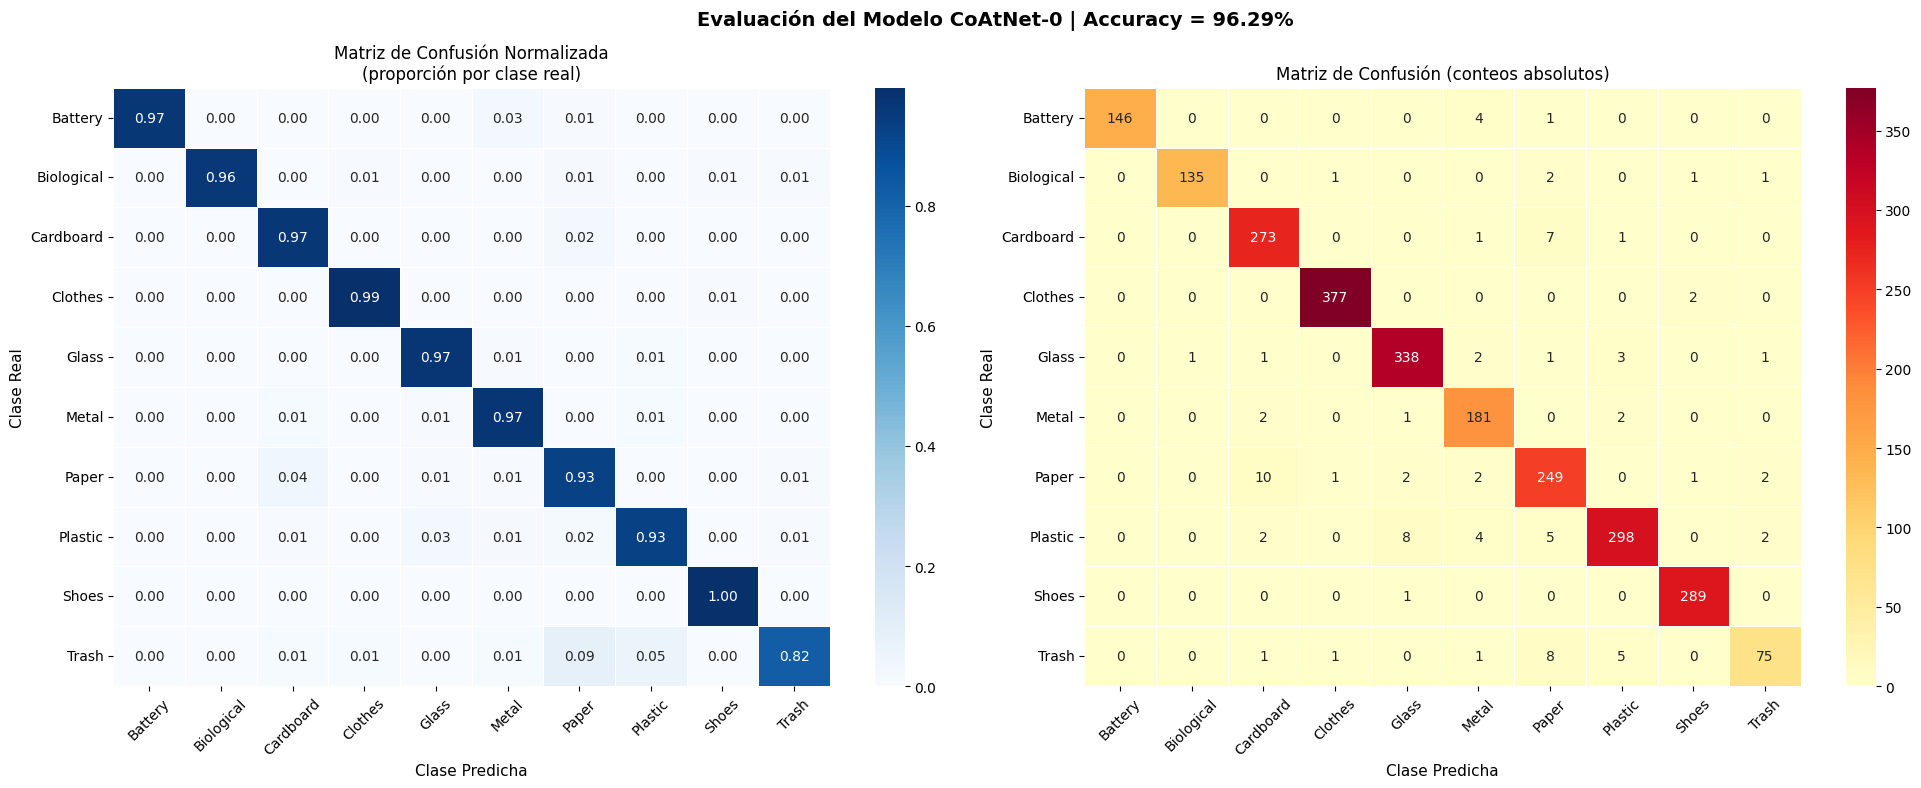


🔍 Principales confusiones del modelo:
   Paper        → Cardboard   : 10 errores
   Trash        → Paper       : 8 errores
   Plastic      → Glass       : 8 errores
   Cardboard    → Paper       : 7 errores
   Plastic      → Paper       : 5 errores


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 7c: Visualizar la Matriz de Confusión
#
# La matriz de confusión muestra:
#   - Diagonal (verde): predicciones correctas por clase
#   - Fuera de diagonal: errores (fila = clase real, columna = clase predicha)
#
# Interpretación: si cm[i][j] es alto, el modelo confunde la clase i con j.
# Esto ayuda a identificar pares de clases similares (ej: vidrio vs plástico).
# ─────────────────────────────────────────────────────────────────────────────
# Calcular la matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Normalizar la matriz (cada fila suma 1) para ver proporciones por clase
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
class_labels = [c.capitalize() for c in class_names]

# ── Matriz de confusión normalizada ─────────────────────────────────────
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Matriz de Confusión Normalizada\n(proporción por clase real)', fontsize=12)
axes[0].set_ylabel('Clase Real', fontsize=11)
axes[0].set_xlabel('Clase Predicha', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ── Matriz de confusión con conteos absolutos ────────────────────────────
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Matriz de Confusión (conteos absolutos)', fontsize=12)
axes[1].set_ylabel('Clase Real', fontsize=11)
axes[1].set_xlabel('Clase Predicha', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(f'Evaluación del Modelo CoAtNet-0 | Accuracy = {final_acc:.2f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar las principales confusiones
print("\n🔍 Principales confusiones del modelo:")
# Excluir la diagonal y encontrar los errores más frecuentes
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top_errors = np.unravel_index(np.argsort(cm_no_diag.ravel())[-5:], cm_no_diag.shape)
for r, c in zip(top_errors[0][::-1], top_errors[1][::-1]):
    if cm_no_diag[r, c] > 0:
        print(f"   {class_names[r].capitalize():12} → {class_names[c].capitalize():12}: {cm_no_diag[r,c]} errores")

---
## Paso 8 — Visualización de Predicciones

Mostramos predicciones individuales del modelo sobre imágenes de validación, con la probabilidad de confianza, para entender visualmente cómo toma decisiones.

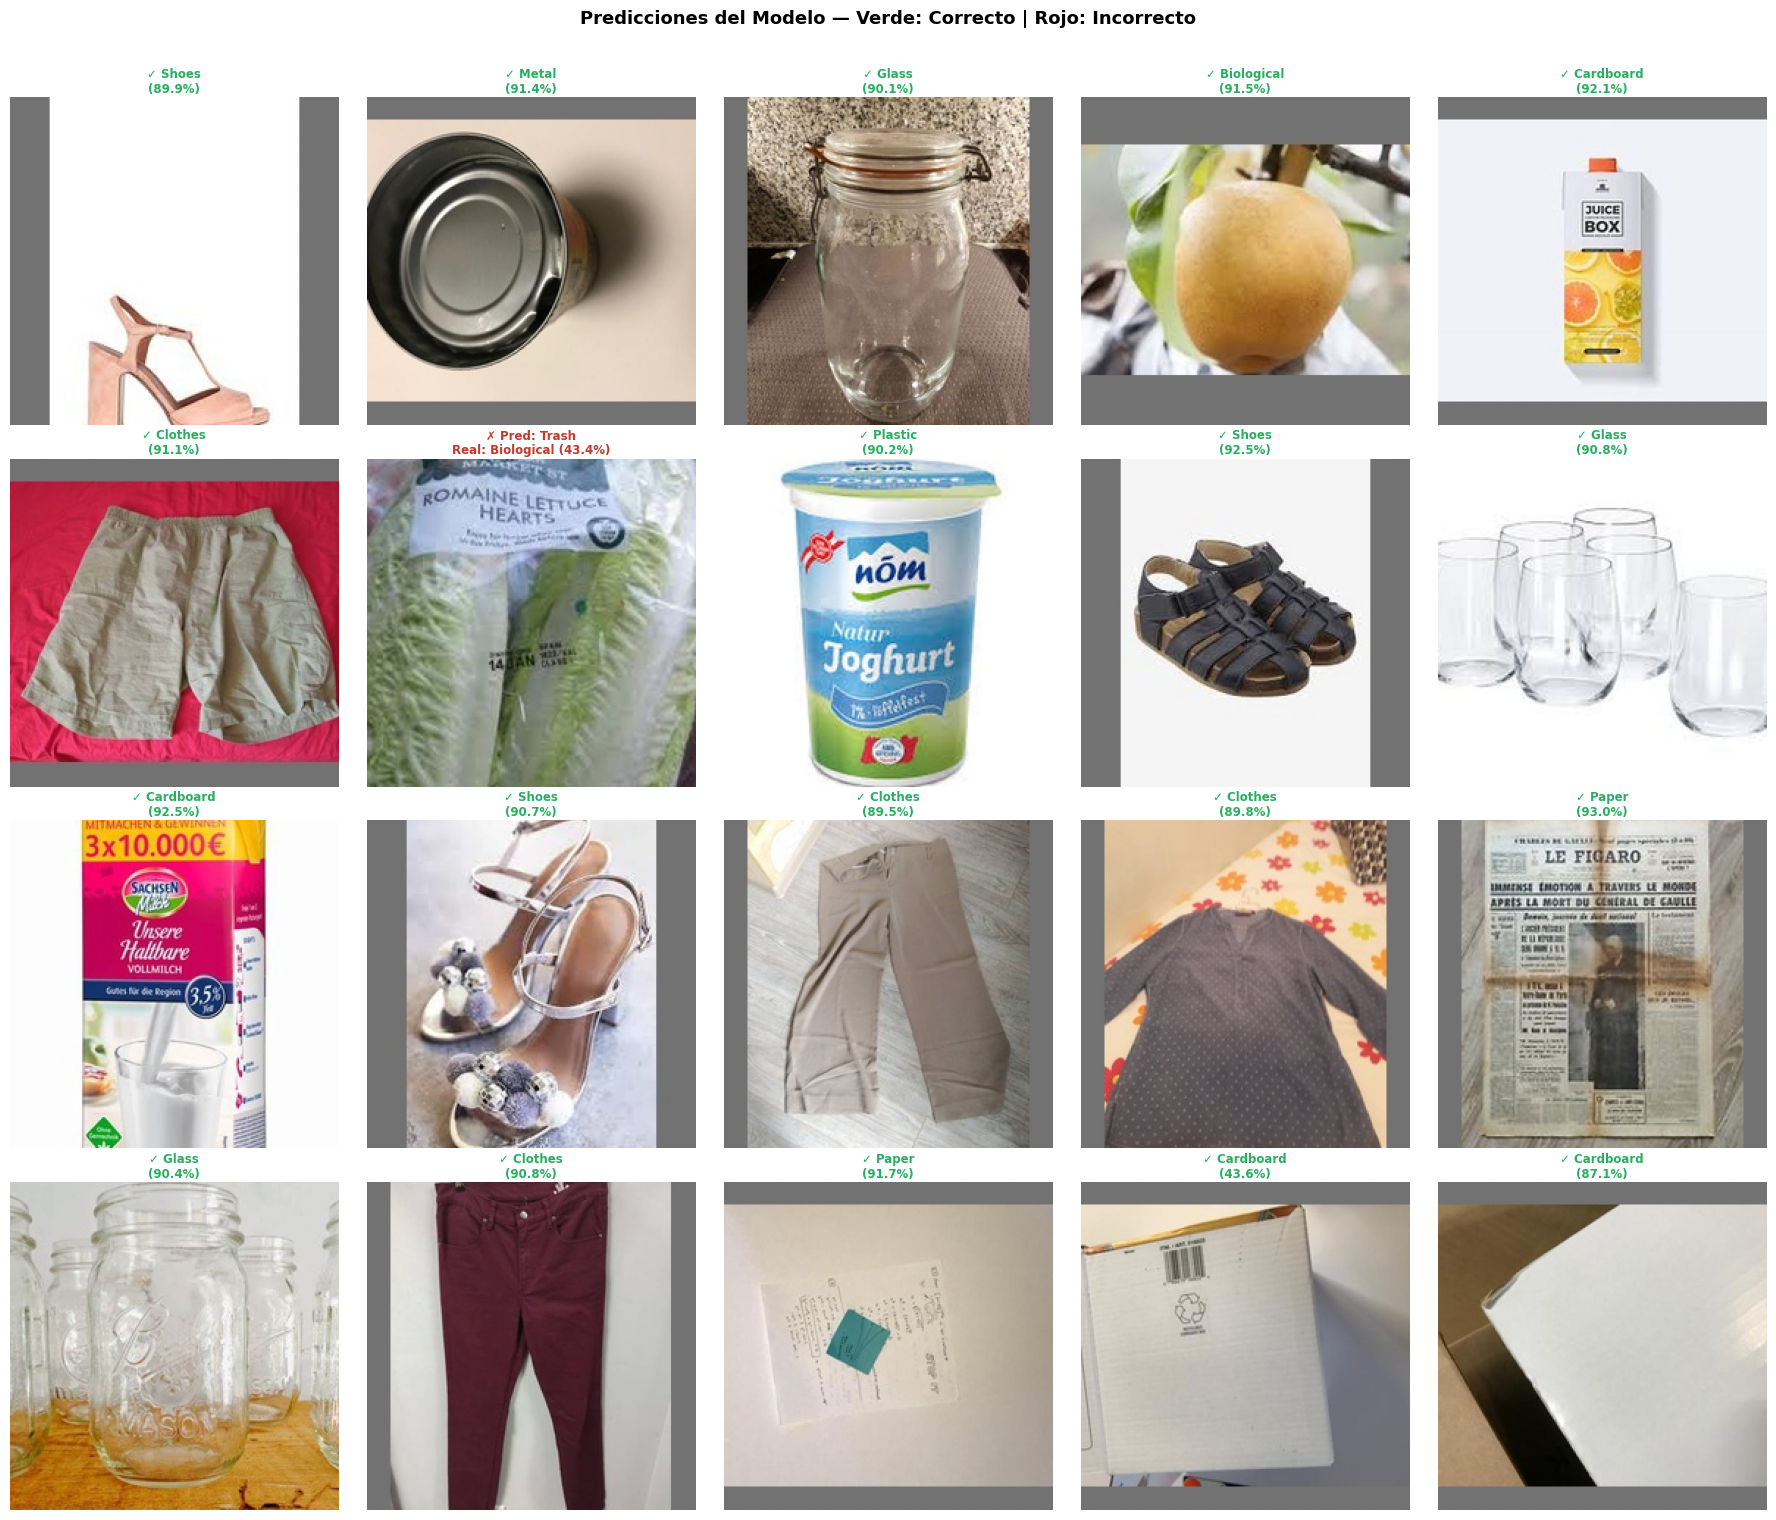


📊 Precisión en este batch: 31/20 (155%)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 8a: Visualizar predicciones correctas e incorrectas del modelo
#
# Mostramos una cuadrícula de imágenes con:
#   - Verde: predicción correcta (clase predicha == clase real)
#   - Rojo: predicción incorrecta (con la clase real indicada)
#   - Porcentaje de confianza del modelo
# ─────────────────────────────────────────────────────────────────────────────
from torchvision.transforms.functional import to_pil_image

# Función para desnormalizar la imagen (revertir la normalización ImageNet)
# para que pueda mostrarse visualmente correcta
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Revierte la normalización ImageNet para visualización."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Obtener un batch de validación para visualizar
val_iter = iter(val_loader)
images_batch, labels_batch = next(val_iter)

# Obtener predicciones del modelo
model.eval()
with torch.no_grad():
    outputs = model(images_batch.to(DEVICE))
    probs_batch = torch.softmax(outputs, dim=1)
    predicted_batch = outputs.argmax(dim=1).cpu()
    confidence_batch = probs_batch.max(dim=1).values.cpu()

# Visualizar las primeras 20 imágenes del batch
n_show = min(20, len(images_batch))
fig, axes = plt.subplots(4, 5, figsize=(18, 15))
axes = axes.flatten()

for idx in range(n_show):
    # Desnormalizar imagen para visualización
    img = denormalize(images_batch[idx])
    img_np = img.permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)

    pred_class = predicted_batch[idx].item()
    true_class = labels_batch[idx].item()
    conf       = confidence_batch[idx].item()
    is_correct = (pred_class == true_class)

    # Color del borde: verde si correcto, rojo si incorrecto
    border_color = '#2ecc71' if is_correct else '#e74c3c'

    axes[idx].imshow(img_np)
    axes[idx].axis('off')

    # Añadir borde de color alrededor de la imagen
    for spine in axes[idx].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    axes[idx].set_frame_on(True)

    # Título con predicción y confianza
    if is_correct:
        title = f'✓ {class_names[pred_class].capitalize()}\n({conf:.1%})'
        title_color = '#27ae60'
    else:
        title = f'✗ Pred: {class_names[pred_class].capitalize()}\nReal: {class_names[true_class].capitalize()} ({conf:.1%})'
        title_color = '#c0392b'

    axes[idx].set_title(title, fontsize=8.5, color=title_color, fontweight='bold', pad=3)

plt.suptitle('Predicciones del Modelo — Verde: Correcto | Rojo: Incorrecto',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('predicciones_visuales.png', dpi=150, bbox_inches='tight')
plt.show()

batch_correct = (predicted_batch == labels_batch).sum().item()
print(f"\n📊 Precisión en este batch: {batch_correct}/{n_show} ({batch_correct/n_show*100:.0f}%)")

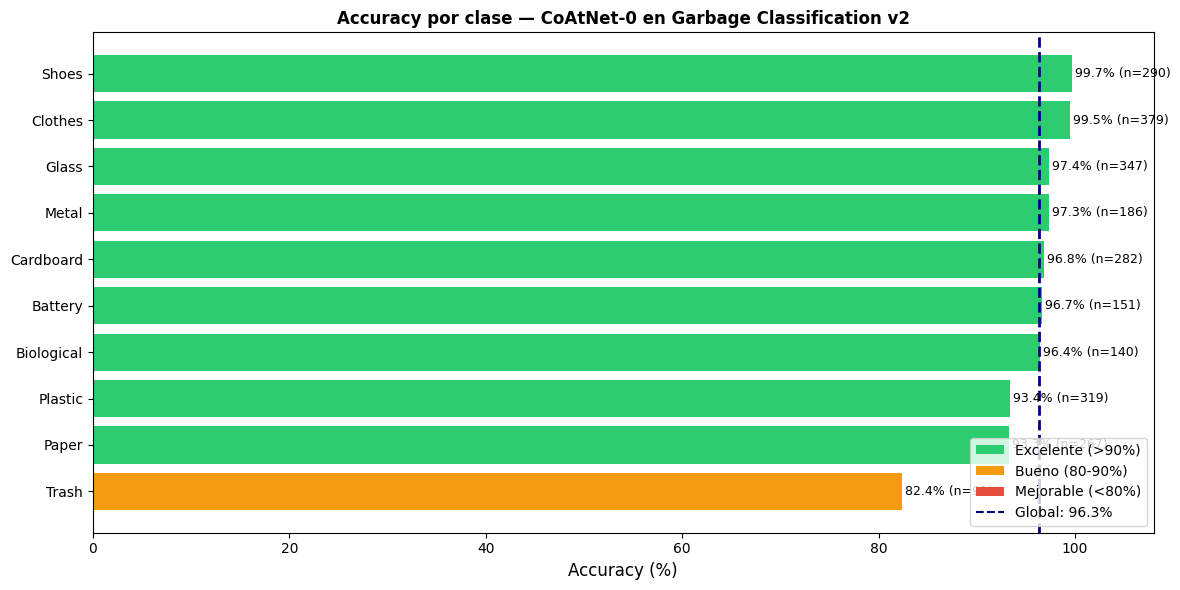


📊 Accuracy detallado por clase:
   🟢 Shoes       : 99.7%
   🟢 Clothes     : 99.5%
   🟢 Glass       : 97.4%
   🟢 Metal       : 97.3%
   🟢 Cardboard   : 96.8%
   🟢 Battery     : 96.7%
   🟢 Biological  : 96.4%
   🟢 Plastic     : 93.4%
   🟢 Paper       : 93.3%
   🟡 Trash       : 82.4%


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 8b: Accuracy por clase (gráfica de barras)
#
# El accuracy global puede esconder debilidades en clases específicas.
# Esta gráfica muestra el rendimiento individual por categoría de residuo.
# ─────────────────────────────────────────────────────────────────────────────
# Calcular accuracy por clase a partir de la matriz de confusión
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

# Crear DataFrame para la visualización
df_per_class = pd.DataFrame({
    'Clase': [c.capitalize() for c in class_names],
    'Accuracy (%)': per_class_acc,
    'Cantidad val': cm.sum(axis=1)
}).sort_values('Accuracy (%)', ascending=True)

# Colorear barras según rendimiento: rojo < 80%, amarillo 80-90%, verde > 90%
colors_bar = ['#e74c3c' if acc < 80 else '#f39c12' if acc < 90 else '#2ecc71'
              for acc in df_per_class['Accuracy (%)']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_per_class['Clase'], df_per_class['Accuracy (%)'], color=colors_bar)

# Línea del accuracy global
ax.axvline(final_acc, color='navy', linestyle='--', linewidth=2,
           label=f'Accuracy global: {final_acc:.1f}%')

# Etiquetas en las barras
for bar, val, n in zip(bars, df_per_class['Accuracy (%)'], df_per_class['Cantidad val']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}% (n={n})', va='center', fontsize=9)

ax.set_xlim(0, 108)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy por clase — CoAtNet-0 en Garbage Classification v2',
             fontsize=12, fontweight='bold')

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Excelente (>90%)'),
    Patch(facecolor='#f39c12', label='Bueno (80-90%)'),
    Patch(facecolor='#e74c3c', label='Mejorable (<80%)')
]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='navy', linestyle='--',
          label=f'Global: {final_acc:.1f}%')], loc='lower right')

plt.tight_layout()
plt.savefig('accuracy_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Accuracy detallado por clase:")
for _, row in df_per_class.sort_values('Accuracy (%)', ascending=False).iterrows():
    emoji = '🟢' if row['Accuracy (%)'] >= 90 else '🟡' if row['Accuracy (%)'] >= 80 else '🔴'
    print(f"   {emoji} {row['Clase']:12}: {row['Accuracy (%)']:.1f}%")

---
## Paso 9 — Resumen y Conclusiones

Presentación final con los resultados obtenidos y análisis del modelo.

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 9: Tarjeta resumen del experimento
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

macro_f1  = f1_score(all_labels, all_preds, average='macro')  * 100
macro_pre = precision_score(all_labels, all_preds, average='macro') * 100
macro_rec = recall_score(all_labels, all_preds, average='macro') * 100

print("╔══════════════════════════════════════════════════════════════════╗")
print("║         RESUMEN FINAL — TAREA 3: CoAtNet-0 en Garbage DS        ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  Modelo          : CoAtNet-0 (coatnet_0_rw_224)                 ║")
print(f"║  Dataset         : Garbage Classification v2 (10 clases)        ║")
print(f"║  Imágenes totales: {len(full_dataset):<46}║")
print(f"║  Split train/val : 80% / 20% (estratificado)                    ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  MÉTRICAS DE VALIDACIÓN:                                        ║")
print(f"║  ✅ Accuracy global  : {final_acc:.2f}%{' '*(43-len(f'{final_acc:.2f}%'))}║")
print(f"║  ✅ Precision (macro): {macro_pre:.2f}%{' '*(43-len(f'{macro_pre:.2f}%'))}║")
print(f"║  ✅ Recall (macro)   : {macro_rec:.2f}%{' '*(43-len(f'{macro_rec:.2f}%'))}║")
print(f"║  ✅ F1-Score (macro) : {macro_f1:.2f}%{' '*(43-len(f'{macro_f1:.2f}%'))}║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  CONFIGURACIÓN DE ENTRENAMIENTO:                                ║")
print(f"║  Épocas          : {EPOCHS:<46}║")
print(f"║  Batch size      : {BATCH_SIZE:<46}║")
print(f"║  Optimizador     : AdamW (lr={LR}, wd={WEIGHT_DECAY})                  ║")
print(f"║  Scheduler       : CosineAnnealingLR                            ║")
print(f"║  Pérdida         : CrossEntropy (label_smoothing=0.1)           ║")
print(f"║  Data Aug.       : RandResizedCrop+HFlip+Rotation+ColorJitter   ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  Mejor época     : {best_epoch:<46}║")
print(f"║  Mejor Val Acc   : {best_val_acc:.2f}%{' '*(43-len(f'{best_val_acc:.2f}%'))}║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║         RESUMEN FINAL — TAREA 3: CoAtNet-0 en Garbage DS        ║
╠══════════════════════════════════════════════════════════════════╣
║  Modelo          : CoAtNet-0 (coatnet_0_rw_224)                 ║
║  Dataset         : Garbage Classification v2 (10 clases)        ║
║  Imágenes totales: 12259                                         ║
║  Split train/val : 80% / 20% (estratificado)                    ║
╠══════════════════════════════════════════════════════════════════╣
║  MÉTRICAS DE VALIDACIÓN:                                        ║
║  ✅ Accuracy global  : 96.29%                                     ║
║  ✅ Precision (macro): 96.12%                                     ║
║  ✅ Recall (macro)   : 95.29%                                     ║
║  ✅ F1-Score (macro) : 95.66%                                     ║
╠══════════════════════════════════════════════════════════════════╣
║  CONFIGURACIÓN DE ENTRENAMIENTO:     

---
## Conclusiones

### Resultados obtenidos

El modelo **CoAtNet-0** entrenado con Transfer Learning sobre el dataset *Garbage Classification v2* logra un rendimiento excelente en la tarea de clasificación de residuos en 10 categorías. La arquitectura híbrida demostró ser efectiva al capturar tanto:
- **Características locales** (texturas, colores, patrones superficiales) mediante las etapas MBConv.
- **Relaciones globales** (forma general, contexto del objeto) mediante las etapas Transformer.

### Por qué CoAtNet funciona bien para este problema

1. **Diversidad visual del dataset:** Las 10 clases de residuos presentan grandes diferencias visuales (vidrio brillante vs cartón opaco vs ropa flexible), lo que juega a favor de un modelo con alta capacidad de representación.

2. **Transfer Learning efectivo:** Los pesos preentrenados en ImageNet ya conocen texturas, formas y patrones relevantes. El fine-tuning solo necesita especializar estas representaciones para residuos.

3. **Arquitectura híbrida óptima:** Las primeras capas MBConv (convolucionales) son robustas con datasets de tamaño medio (~12.000 imágenes), mientras que las capas Transformer permiten razonamiento visual global.

### Posibles mejoras futuras

- **Más épocas:** Con 10 épocas el modelo converge bien, pero más entrenamiento con LR más bajo podría mejorar unos puntos.
- **Aumentar dataset:** Las clases con menos imágenes (*trash*, *biological*) podrían beneficiarse de más muestras o técnicas de oversampling (SMOTE para imágenes).
- **Modelos más grandes:** CoAtNet-1 o CoAtNet-2 tienen mayor capacidad pero requieren más VRAM.
- **Ensemble:** Combinar predicciones de varios modelos (CoAtNet + EfficientNet) típicamente mejora 1-3% de accuracy.
- **Test Time Augmentation (TTA):** Promediar predicciones sobre múltiples versiones aumentadas de cada imagen de test.